## Multiple Linear Regression
Multiple Linear Regression means having more than one independent feature predicting a single dependent feature (unlike simple linear regression, which uses only one).
- Dataset is 24 monthly records across 2 years.
- Index Price is a measure of relative price changes over time, calculated using interest and unemployement rate

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv('economic_index.csv')
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


Since Unnamed, year, month are unnecessary columns -- we should drop em

In [8]:
df.drop(columns=['Unnamed: 0', 'year', 'month'], inplace=True)
print(df.columns)

Index(['interest_rate', 'unemployment_rate', 'index_price'], dtype='str')


In [9]:
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

In [10]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


- Interest Rate <-> Unemployment Rate and Index Price <-> Unemployment Rate = Negative Correlation (One increase and Other Decrease).
- Interest Rate <-> Index Price = Positive Correlation (One increase and Other also increase)
- Since both correlate highly, both are meaningful for prediction

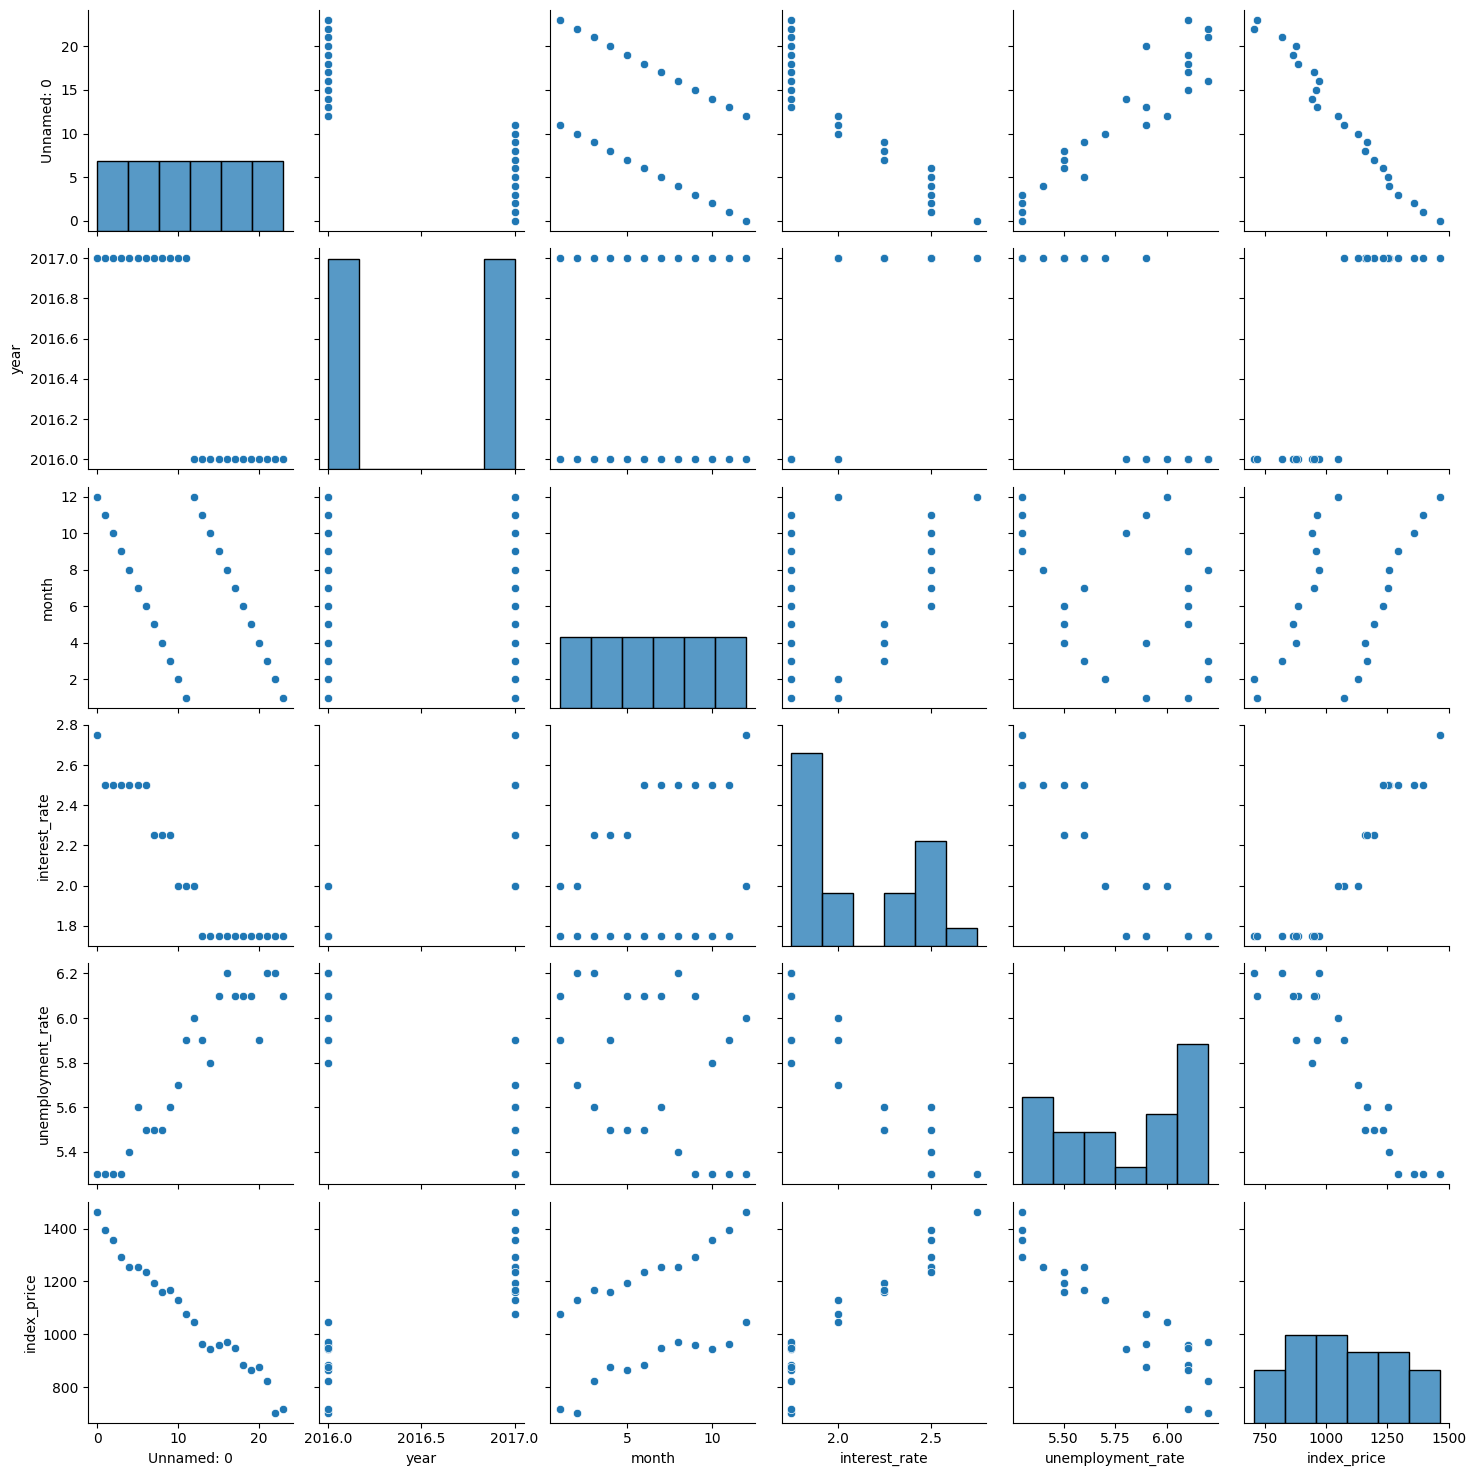

In [ ]:
sns.pairplot(df)
plt.show()

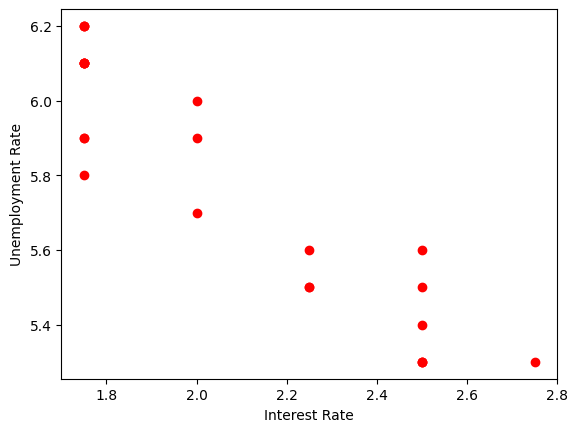

In [19]:
plt.scatter(df['interest_rate'], df['unemployment_rate'], color='r')
plt.xlabel('Interest Rate')
plt.ylabel('Unemployment Rate')
plt.show()
#This not needed to draw as sns pairplot already gives this

<Axes: xlabel='unemployment_rate', ylabel='interest_rate'>

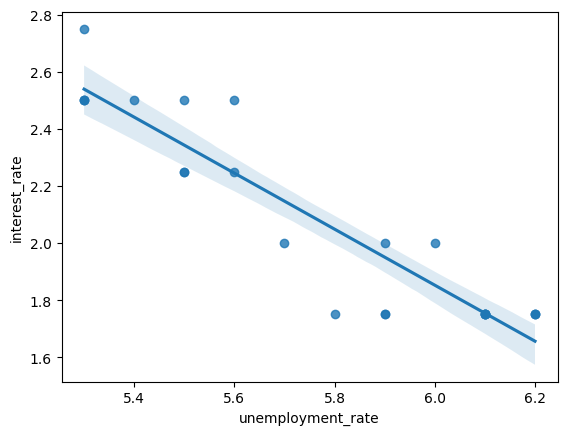

In [21]:
sns.regplot(x=df['unemployment_rate'],y=df['interest_rate'])

regplot plots the data points and fits a linear regression line through them in one step, giving a quick visual sense of how well a linear relationship explains the data. The shaded region around the line represents the confidence interval.

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

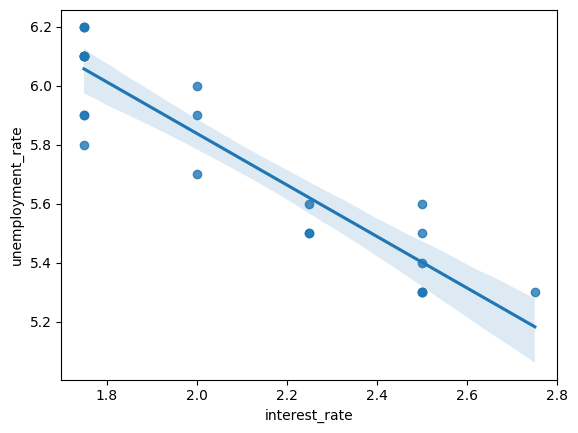

In [26]:
sns.regplot(x=df['interest_rate'], y=df['unemployment_rate'])

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

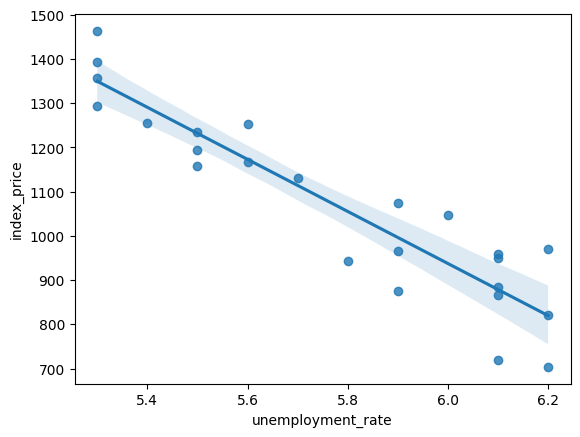

In [27]:
sns.regplot(x=df['unemployment_rate'], y=df['index_price'])

We have Dependent Feature = Index Rate and other 2 = Independent so split them

In [28]:
X = df[['unemployment_rate', 'interest_rate']]
y = df['index_price']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)
model = LinearRegression()

In [30]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [35]:
print("Coefficient/Slope:", model.coef_)
print("Intercept:", model.intercept_)
print(X.dtypes)

Coefficient/Slope: [-116.25716066   88.27275507]
Intercept: 1053.4444444444443
unemployment_rate    float64
interest_rate        float64
dtype: object


d:\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


Text(0.5, 0.92, 'Multiple Linear Regression Best Fit Line (3D)')

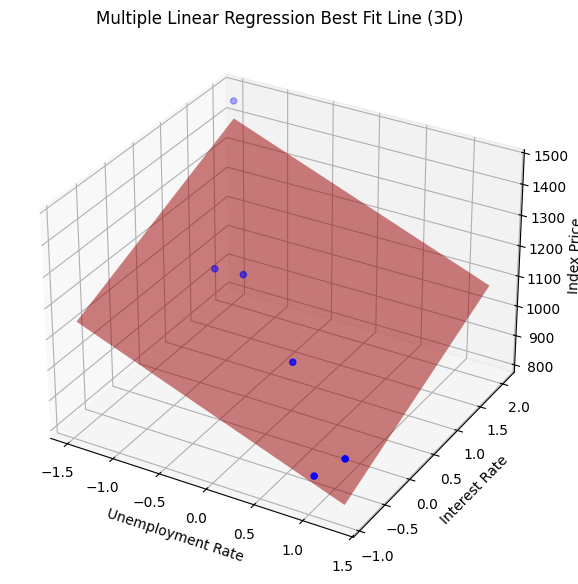

In [37]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
X_test_df = pd.DataFrame(X_test, columns=['unemployment_rate', 'interest_rate'])
#because scaling converted it from dataframe to numpy 
ax.scatter(X_test_df['unemployment_rate'], X_test_df['interest_rate'],
           y_test, color='blue', label='Actual Data')

x1_range = np.linspace(X_test_df['unemployment_rate'].min(), X_test_df['unemployment_rate'].max(), 100)
x2_range = np.linspace(X_test_df['interest_rate'].min(), X_test_df['interest_rate'].max(), 100)
x1, x2 = np.meshgrid(x1_range, x2_range)

grid_df = pd.DataFrame({
    'unemployment_rate': x1.ravel(),
    'interest_rate': x2.ravel()
})
z = model.predict(grid_df).reshape(x1.shape)
ax.plot_surface(x1, x2, z, color='red', alpha=0.5, rstride=100, cstride=100)

ax.set_xlabel('Unemployment Rate')
ax.set_ylabel('Interest Rate')
ax.set_zlabel('Index Price')
ax.set_title('Multiple Linear Regression Best Fit Line (3D)')

In [38]:
y_pred = model.predict(X_test)

## Cross Validation
This gives the average MSE across all 5 folds — a more robust performance estimate than relying on a single split.

In [40]:
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(
    model, X_train, y_train,
    scoring = 'neg_mean_squared_error',
    cv=5
)
mean_val_score = np.mean(validation_score)
print(mean_val_score)

-5649.115244350762


## Check Model Assumptions
After building the model, three diagnostic checks confirm whether a linear regression model is actually appropriate for this data

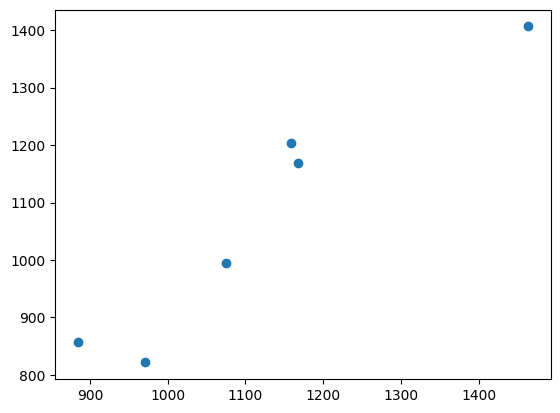

In [ ]:
plt.scatter(y_test,y_pred) #If plot follows a linear path, model is good

<Axes: xlabel='index_price', ylabel='Density'>

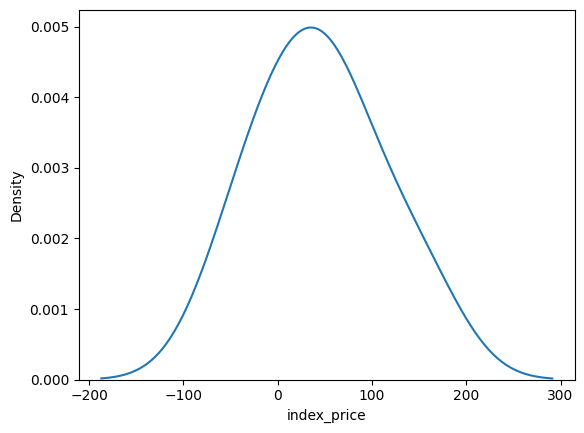

In [43]:
residuals = y_test - y_pred
sns.kdeplot(residuals)  #errors b/w actual and predicted, if residuals form normal dist then validity of our model is supported

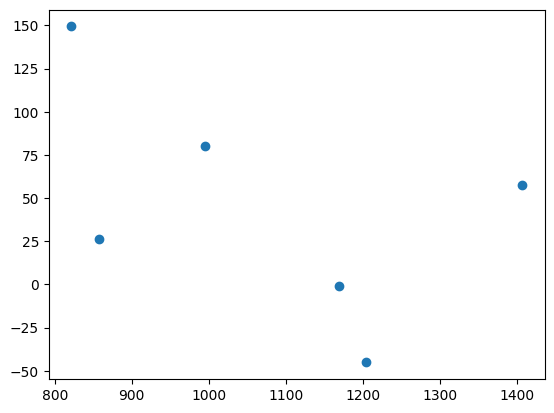

In [45]:
plt.scatter(y_pred, residuals)  #randomly scattered means good model no biasness